# **Lecture:** Train a CNN for image classification with PyTorch

### **Step 1: Load CIFAR-10**

In [1]:
# Load CIFAR-10 dataset from PyTorch
from torchvision import datasets, transforms
cifar10_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
cifar10_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

Files already downloaded and verified
Files already downloaded and verified


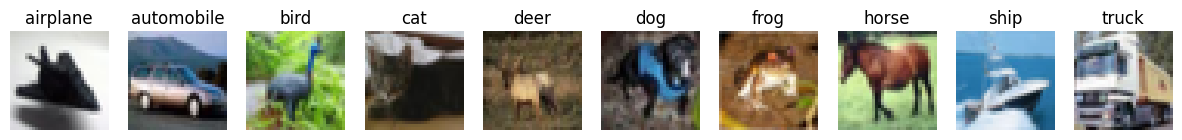

In [2]:
# Vizualize one image per class
import matplotlib.pyplot as plt
import numpy as np
classes = cifar10_train.classes
class_to_idx = cifar10_train.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))
for i, class_name in enumerate(classes):
    class_idx = class_to_idx[class_name]
    for img, label in cifar10_train:
        if label == class_idx:
            axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
            axes[i].set_title(class_name)
            axes[i].axis('off')
            break
plt.show()

### **Step 2: Classifier Flatten + KNN**

In [3]:
# A classifier by flattening the images and using a linear classifier KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
X_train = cifar10_train.data.reshape(len(cifar10_train), -1)
y_train = cifar10_train.targets
X_test = cifar10_test.data.reshape(len(cifar10_test), -1)
y_test = cifar10_test.targets
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'KNN Accuracy: {accuracy:.4f}')

KNN Accuracy: 0.3398


In [4]:
# Create a classifier by flattening the images and using a linear classifier Logistic Regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=50)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f'Logistic Regression Accuracy: {accuracy_logreg:.4f}')

Logistic Regression Accuracy: 0.3933


/Users/eugenio/Documents/Computer_Vision/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### **Step 3: Classifier basic feature extraction + Logistic Regression**

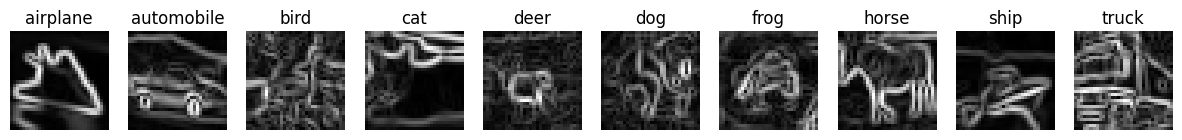

In [5]:
# Create a classifier by extracting basic features (sobel filters) and using a linear classifier Logistic Regression, visualizing the features (one for each class)
from skimage.filters import sobel

def extract_sobel_features(image):
    gray = np.mean(image, axis=2)
    features = sobel(gray)
    return features.flatten()

# Visualize the sobel activation map for one image per class
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))
for i, class_name in enumerate(classes):
    class_idx = class_to_idx[class_name]
    for img, label in cifar10_train:
        if label == class_idx:
            sobel_features = extract_sobel_features(img.numpy().transpose(1, 2, 0))
            axes[i].imshow(sobel_features.reshape(32, 32), cmap='gray')
            axes[i].set_title(class_name)
            axes[i].axis('off')
            break   
plt.show()


In [8]:
# Create a classifier by extracting basic features (sobel filters) and using a linear classifier Logistic Regression
X_train_sobel = np.array([extract_sobel_features(img) for img in cifar10_train.data])
X_test_sobel = np.array([extract_sobel_features(img) for img in cifar10_test.data])

logreg_sobel = LogisticRegression(max_iter=50)
logreg_sobel.fit(X_train_sobel, y_train)
y_pred_logreg_sobel = logreg_sobel.predict(X_test_sobel)
accuracy_logreg_sobel = accuracy_score(y_test, y_pred_logreg_sobel)
print(f'Logistic Regression with Sobel Features Accuracy: {accuracy_logreg_sobel:.4f}')

Logistic Regression with Sobel Features Accuracy: 0.2941


/Users/eugenio/Documents/Computer_Vision/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### **Step 4: Classifier basic feature extraction + Fully-Connected Neural Network**

In [9]:
# Classifier basic feature extraction + Fully-Connected Neural Network
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=50)
mlp.fit(X_train_sobel, y_train)
y_pred_mlp = mlp.predict(X_test_sobel)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f'MLP with Sobel Features Accuracy: {accuracy_mlp:.4f}')

MLP with Sobel Features Accuracy: 0.2817


/Users/eugenio/Documents/Computer_Vision/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


### **Step 5: Feature Extraction using Convolutional Layers + Fully-Connected Neural Network**

In [ ]:
# Importamos PyTorch
import torch

# Importamos el módulo de redes neuronales
import torch.nn as nn

# DataLoader nos permite trabajar con mini-batches (como batch_size en Keras)
from torch.utils.data import DataLoader

# Detectamos si hay GPU disponible, si no usamos CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Definimos el modelo usando nn.Sequential (similar a tf.keras.Sequential)
model = nn.Sequential(
    
    # Capa convolucional:
    # 3 canales de entrada (RGB)
    # 16 filtros
    # kernel 3x3
    # padding=1 mantiene el tamaño espacial
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    
    # Función de activación ReLU
    nn.ReLU(),
    
    # MaxPooling 2x2 (reduce a la mitad el tamaño de la imagen)
    nn.MaxPool2d(2),
    
    # Aplana el tensor para pasarlo a la capa fully connected
    nn.Flatten(),
    
    # Capa totalmente conectada
    # 16 canales * 16 * 16 (depende del tamaño de la imagen CIFAR-10: 32x32)
    # 10 salidas (10 clases)
    nn.Linear(16 * 16 * 16, 10)

# Enviamos el modelo a GPU o CPU
).to(device)

# Definimos la función de pérdida
# CrossEntropyLoss ya incluye Softmax internamente
criterion = nn.CrossEntropyLoss()

# Definimos el optimizador (Adam)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# Creamos los DataLoaders
# batch_size=64 → tamaño del mini-batch
# shuffle=True → mezcla los datos en cada época
train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True)
test_loader  = DataLoader(cifar10_test,  batch_size=64)

# =========================
# ENTRENAMIENTO
# =========================

for epoch in range(5):  # Entrenamos por 5 épocas
    
    model.train()  # Modo entrenamiento (activa dropout, batchnorm si existieran)
    
    for x, y in train_loader:  # Recorremos mini-batches
        
        # Movemos datos a GPU/CPU
        x, y = x.to(device), y.to(device)

        # Reiniciamos gradientes (muy importante en PyTorch)
        optimizer.zero_grad()
        
        # Forward pass (predicción)
        outputs = model(x)
        
        # Calculamos la pérdida
        loss = criterion(outputs, y)
        
        # Backpropagation
        loss.backward()
        
        # Actualizamos pesos
        optimizer.step()

# =========================
# EVALUACIÓN
# =========================

model.eval()  # Modo evaluación (desactiva dropout, etc.)

correct = 0  # Contador de predicciones correctas

# Desactivamos cálculo de gradientes (más rápido y menos memoria)
with torch.no_grad():
    
    for x, y in test_loader:
        
        # Movemos datos a GPU/CPU
        x, y = x.to(device), y.to(device)
        
        # Forward pass
        outputs = model(x)
        
        # Tomamos la clase con mayor probabilidad
        preds = outputs.argmax(dim=1)
        
        # Contamos cuántas predicciones fueron correctas
        correct += (preds == y).sum().item()

# Calculamos accuracy final
accuracy = correct / len(cifar10_test)

# Mostramos resultado
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6032


In [ ]:
# Importamos PyTorch
import torch

# Importamos el módulo para construir redes neuronales
import torch.nn as nn

# DataLoader permite trabajar con mini-batches
from torch.utils.data import DataLoader


# Detectamos si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# DEFINICIÓN DEL MODELO
# =========================

# Creamos una clase que hereda de nn.Module
class SimpleCNN(nn.Module):
    
    def __init__(self):
        # Llamamos al constructor de la clase padre
        super().__init__()
        
        # Capa convolucional:
        # 3 canales de entrada (RGB)
        # 16 filtros
        # kernel 3x3
        # padding=1 mantiene tamaño espacial
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        
        # Capa de MaxPooling 2x2 (reduce dimensiones a la mitad)
        self.pool = nn.MaxPool2d(2)
        
        # Capa totalmente conectada
        # CIFAR-10 es 32x32
        # Después de conv + pool → 16 canales de 16x16
        # 16 * 16 * 16 = 4096
        self.fc1 = nn.Linear(16 * 16 * 16, 10)  # 10 clases

    # Método forward (define cómo fluye la información)
    def forward(self, x):
        
        # Aplicamos convolución + ReLU + pooling
        x = self.pool(torch.relu(self.conv1(x)))
        
        # Aplanamos el tensor para la capa fully connected
        x = torch.flatten(x, 1)  # 1 = mantiene dimensión batch
        
        # Capa final
        x = self.fc1(x)
        
        return x

# Creamos el modelo y lo enviamos a GPU/CPU
model = SimpleCNN().to(device)

# =========================
# CONFIGURACIÓN
# =========================

# Función de pérdida (incluye Softmax internamente)
criterion = nn.CrossEntropyLoss()

# Optimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# DataLoaders
train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True)
test_loader  = DataLoader(cifar10_test, batch_size=64)

# =========================
# ENTRENAMIENTO
# =========================

for epoch in range(5):  # 5 épocas
    
    model.train()  # Modo entrenamiento
    
    for x, y in train_loader:
        
        # Movemos datos a GPU/CPU
        x, y = x.to(device), y.to(device)
        
        # Reiniciamos gradientes
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(x)
        
        # Calculamos pérdida
        loss = criterion(outputs, y)
        
        # Backpropagation
        loss.backward()
        
        # Actualizamos pesos
        optimizer.step()

# =========================
# EVALUACIÓN
# =========================

model.eval()  # Modo evaluación

correct = 0  # Contador de aciertos

# Desactivamos gradientes para evaluación
with torch.no_grad():
    
    for x, y in test_loader:
        
        x, y = x.to(device), y.to(device)
        
        # Forward pass
        outputs = model(x)
        
        # Tomamos la clase con mayor valor
        preds = outputs.argmax(dim=1)
        
        # Sumamos aciertos
        correct += (preds == y).sum().item()

# Calculamos accuracy
accuracy = correct / len(cifar10_test)

print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.5827


In [10]:
# Super basic CNN with PyTorch computing the accuracy on the test set
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 16 * 16, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc1(x)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True)
for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
model.eval()
test_loader = DataLoader(cifar10_test, batch_size=64, shuffle=False)
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy_cnn = correct / total
print(f'Simple CNN Accuracy: {accuracy_cnn:.4f}')

Simple CNN Accuracy: 0.6023


---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>